### 01. Introduction
freMTPL2freq dataset is a set of data on french motor insurance. 
We import this dataset into a dataframe for exploratory data analysis.
IDpol: The policy ID (used to link with the claims dataset).
ClaimNb: Number of claims during the exposure period.

Exposure: The period of exposure for a policy, in years.
VehPower: The power of the car (ordered values).
VehAge: The vehicle age, in years.
DrivAge: The driver age, in years (in France, people can drive a car at 18).
BonusMalus: Bonus/malus, between 50 and 350: <100 means bonus, >100 means malus in France.
VehBrand: The car brand (unknown categories).
VehGas: The car gas, Diesel or regular.
Area: The density value of the city community where the car driver lives in: from "A" for rural area to "F" for urban centre.
Density: The density of inhabitants (number of inhabitants per square-kilometer) of the city where the car driver lives in.
Region: The policy region in France (based on the 1970-2015 classification).

In [2]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
full_motor_data = fetch_openml(data_id=43593, as_frame=True, parser="auto")
df = full_motor_data.frame

df.head(5)

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


### 02. Dataset overview

In [3]:
print("Shape:", df.shape)
print("\nTypes:\n",df.dtypes)
print("\nDescription:\n",df.describe().round(2))

Shape: (678013, 11)

Types:
 ClaimNb         int64
Exposure      float64
Area           object
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Density         int64
Region         object
dtype: object

Description:
          ClaimNb   Exposure   VehPower     VehAge    DrivAge  BonusMalus  \
count  678013.00  678013.00  678013.00  678013.00  678013.00   678013.00   
mean        0.05       0.53       6.45       7.04      45.50       59.76   
std         0.24       0.36       2.05       5.67      14.14       15.64   
min         0.00       0.00       4.00       0.00      18.00       50.00   
25%         0.00       0.18       5.00       2.00      34.00       50.00   
50%         0.00       0.49       6.00       6.00      44.00       50.00   
75%         0.00       0.99       7.00      11.00      55.00       64.00   
max        16.00       2.01      15.00     100.00     100.00      230.00   

         Densit

### 03. ClaimNb analysis

We can see that the overwhelming majority of cases have no claims

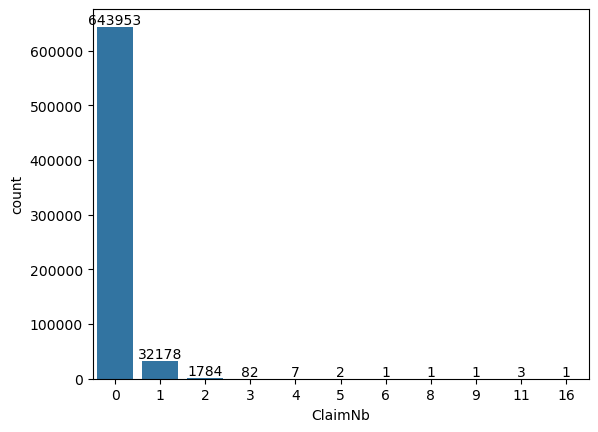

Proportion with claims: 5.02 %


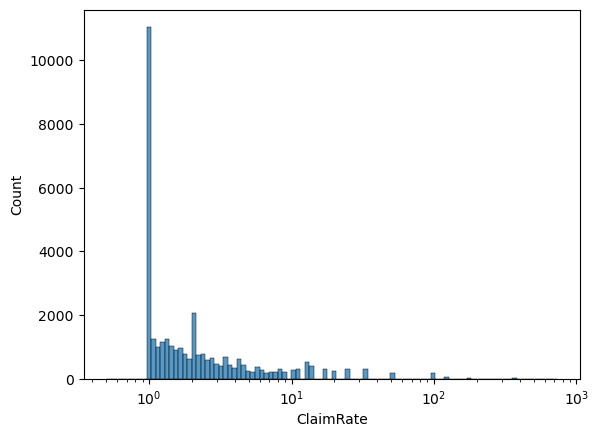

In [48]:
ax = sns.countplot(x="ClaimNb",data=df)
for bar in ax.containers:
    ax.bar_label(bar)

plt.show()

df["ClaimRate"] = df["ClaimNb"] / df["Exposure"]

sns.histplot(df["ClaimRate"], bins = 100,log_scale=True)

print(f"Proportion with claims: {((df['ClaimNb'] > 0).mean() * 100):.2f} %")



### 04. Distributions
Categorical data have the following maxxed values:
Region: Centre-Val de Loire

Feature max:
Exposure: 1.0
Area: C
VehPower: 6
VehAge: 0
DrivAge: 51
BonusMalus: 50
VehBrand: B12
VehGas: Regular
Density: 27000
Region: R24


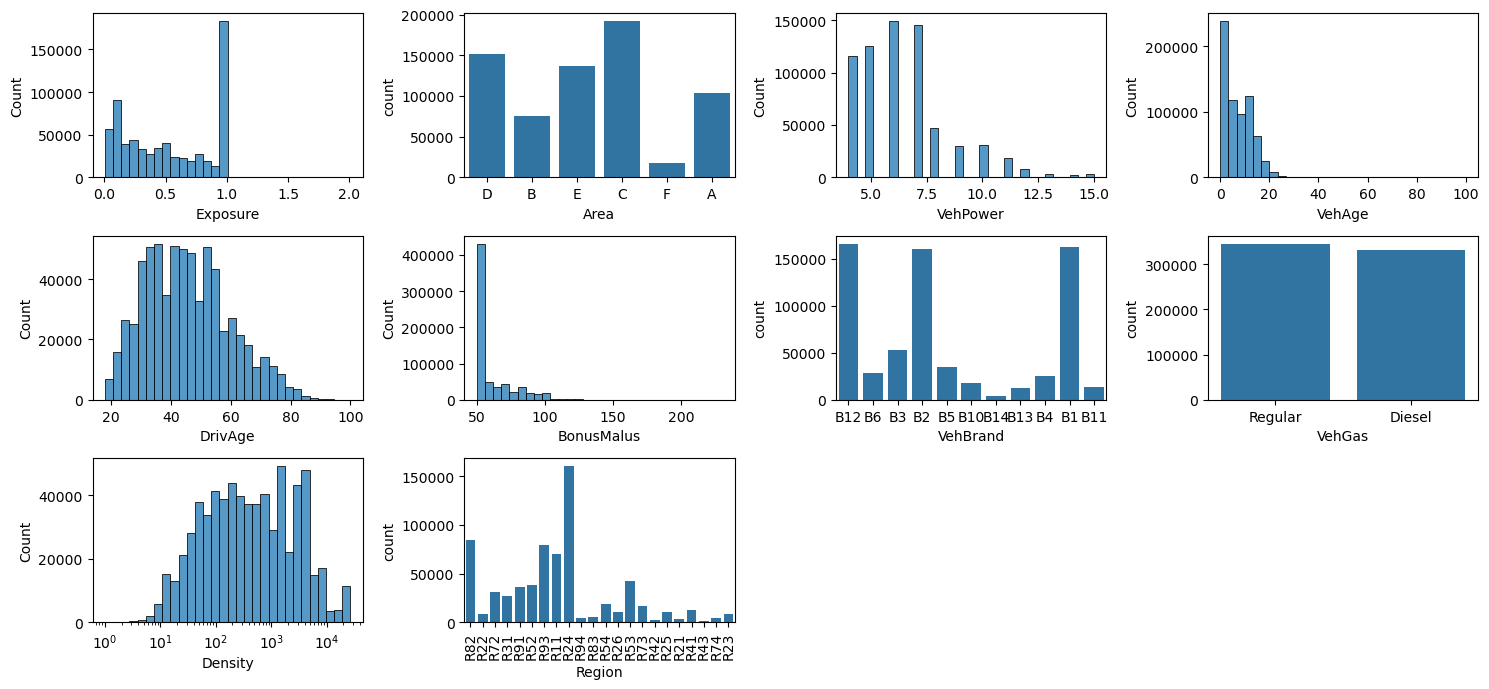

In [58]:
fig, axes = plt.subplots(3, 4, figsize=(15,7))
axes = axes.flatten()

features = list(df.columns.values)
del features[0:1]
del features[-1]

features_numerical = ["Exposure","VehPower","VehAge","DrivAge","BonusMalus","Density"]
features_categorical = ["Area","VehBrand","VehGas","Region"]

print("Feature max:")


for feature, ax in zip(features,axes):
    if feature in features_numerical:
        if feature == "Density":
                sns.histplot(df[feature],bins=30,ax=ax,log_scale=True)
        else:
            sns.histplot(df[feature],bins=30,ax=ax)
    elif feature in features_categorical:
        sns.countplot(x=df[feature],ax=ax)

    if feature == "Region":
                plt.setp(ax.get_xticklabels(), rotation=90)
                


    print(f"{feature}: {(df.groupby(feature)['ClaimNb'].sum()).idxmax()}")

for ax in axes[len(features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

